<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Time Series Analysis <a class="tocSkip">

In this notebook we will cover:

- What time series are and how to characterize them
- Frequency-domain analysis: FFT and Power Spectral Density
- Fitting the PSD with power laws
- Irregular sampling and CARMA models



# Setup

In [1]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


In [2]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Optional
from scipy.optimize import curve_fit, minimize
import emcee
from scipy.linalg import cho_factor, cho_solve
import matplotlib.pyplot as plt

# What is a Time Series?

<u>General Time Series:</u> A set of observations $x_t$, each one recorded at a specific time $t$.

We can have:

- <u>Discrete time</u> series, where the set $T_0$ of times at which observations are made is a discrete set (observations at fixed intervals).

- <u>Continuous time</u> series, where observations are recorded continuously over a time interval.


<img src="images/oogway_lightcurve.png" width=900 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=900><center><br>
    Figure 0. Wise words for every astronomer working with light curves.
<br></center></td></tr></table>


**Why are time series useful in Astronomy / Astrophysics?**
1. Discovery of new objects
2. Probing inaccessible physical scales
3. Triggering follow-up observations
4. Signal detection
5. Applications extend to industry, economics, banking, and more!

**Application fields:** Cosmology, Exoplanets, Accretion physics, Stellar physics, Multi-messenger astronomy

<u>**Objective of Time Series Analysis**</u>

Build a model capable of describing the series, predicting future values, and testing hypotheses (a classic non-astronomy example is global warming).

## Simple Time Series Modeling

We need to account for the unpredictable nature of future observations, so we assume that each observation $x_t$ is a realized value of a random variable $X_t$.

<u>Definition of a **Time Series Model**:</u>

For the observed data $\{x_t\}$, the time series model is a specification of the joint distribution (sometimes only the means and covariances are needed) of a sequence of random variables $\{X_t\}$, of which $\{x_t\}$ is postulated to be a realization.

$$P[X_1 \leq x_1, \dots , X_n \leq x_n], \quad - \infty < x_1, \dots , x_n < \infty, \quad n = 1,2,3 \dots$$

*(Sometimes "time series" refers to both the data and the model that describes it.)*

A general time series can have the following components:
1. Trend
2. Seasonal component
3. Random / residual component
4. Noise

And can be decomposed as:
$$x(t) = \text{Trend}(t) + \text{Seasonality}(t) + \text{Random}(t) + \text{Noise}(t) \tag{1}$$


# Stationary Random Process
 
**Strong (Strict) Stationarity:**

A time series is strongly stationary if, for every $n \geq 1$, every choice of times $t_1, t_2, \dots , t_n$, and time shift $h \in \mathbb{Z}$, the joint distribution satisfies:

$$
(X_{t_1}, X_{t_2}, \dots , X_{t_n}) \stackrel{d}{=} (X_{t_1+h}, X_{t_2+h}, \dots , X_{t_n+h})
$$

The statistical properties are invariant under time shifts.

> _In simple words: the joint distribution is identical to that of any time-shifted version._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

**Weak Stationarity**

*Reminder:* $\mathbb{E}$ is the expectation (or expected value) operator. $\mathbb{E}[X]$ is a single number representing the "average value" of the random variable $X$, weighted by the probabilities of its outcomes.

A time series $X_t$ is weakly stationary (second-order stationary) if:

1. $\mathbb{E}[X_t^2] < \infty$ (the series converges to a finite number)
2. $\mathbb{E}[X_t] = \mu$ is constant in $t$
3. $\text{Cov}(X_t, X_{t+h}) = \gamma(h)$, depends only on the lag (time shift) $h$ and not on $t$

_We present these for completeness — we will not dwell on them._

Where the covariance is defined as:

$$
\text{Cov}(X,Y) = \mathbb{E}\left([X - \mathbb{E}[X]][Y - \mathbb{E}[Y]]\right)
$$

We also define the **autocovariance function (ACVF)**, which is the covariance of the time series with a shifted version of itself:

$$
\gamma(h) = \text{Cov}(X_t, X_{t+h}) = \text{Cov}(X_{t+h}, X_t) = \mathbb{E}\left([X_t - \mathbb{E}[X_t]][X_{t+h} - \mathbb{E}[X_{t+h}]]\right)
$$

Furthermore, the **autocorrelation function (ACF)** is defined as:

$$
\text{Cor}(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}}
$$

$$
\text{ACF} = \rho(h) = \frac{\gamma(h)}{\gamma(0)} = \frac{\text{Cov}(X_t, X_{t+h})}{\text{Var}(X_t)}
$$

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

> _In simple words: **weak stationarity** means the mean and autocovariance are the same regardless of when you start observing._


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [2 min]**</font>

**What would the ACF look like for a purely white-noise process?**<br>
_Hint: if every observation is independent, what is $\text{Cov}(X_t, X_{t+h})$ for $h \neq 0$?_<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

For white noise, $\text{Cov}(X_t, X_{t+h}) = 0$ for all $h \neq 0$, so $\rho(h) = 0$ for $h \neq 0$ and $\rho(0) = 1$. The ACF is a single spike at zero and nothing elsewhere. In the PSD this corresponds to a **flat (white) spectrum** equal power at all frequencies. The correlated light curves we study today have $\rho(h) \neq 0$ for small $h$.

</details>
</div>

# Calculation of Those Metrics for Discrete Data

_The following formulas are presented for completeness._

Let $x_1, \ldots, x_n$ be observations of a time series. The **sample mean** of $x_1, \ldots, x_n$ is

$$
\bar{x} = \frac{1}{n} \sum_{t=1}^{n} x_t.
$$

The **sample autocovariance function** is

$$
\hat{\gamma}(h) := n^{-1} \sum_{t=1}^{n-|h|} (x_{t+|h|} - \bar{x})(x_t - \bar{x}), \quad -n < h < n.
$$

The **sample autocorrelation function** is

$$
\hat{\rho}(h) = \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}, \quad -n < h < n.
$$


# Regularly Sampled Light Curves of an AGN





## Load and Visualize the Data

In [3]:
simple_lc = pd.read_csv("data/Lc_ungapped.csv")
display(simple_lc.head())


,time_days,rate_emm13,rate_source,rate_bkg,rate_total,err
0,0.0,0.008117,0.007986,0.000324,0.008310,0.000446
1,0.5,0.011245,0.010995,0.000278,0.011273,0.000517
2,1.0,0.010686,0.012037,0.000185,0.012222,0.000538
3,1.5,0.008093,0.007407,0.000185,0.007593,0.000427
4,2.0,0.008191,0.008333,0.000255,0.008588,0.000453


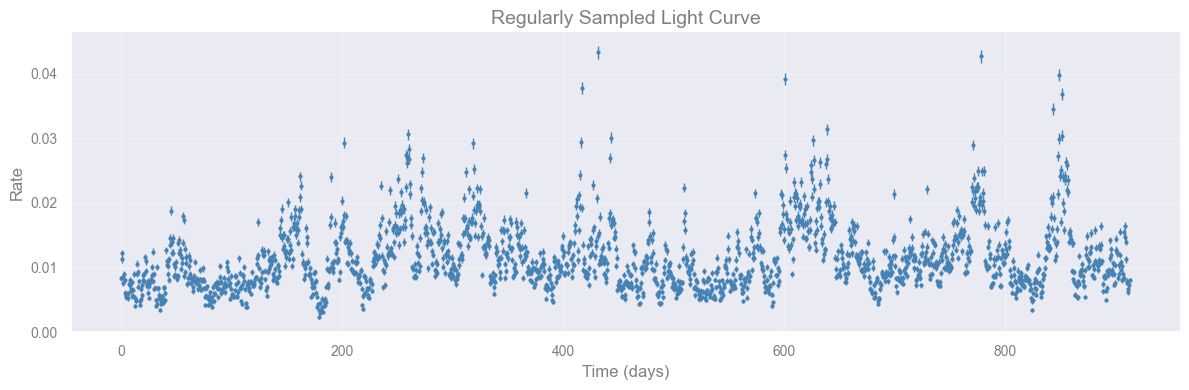

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    simple_lc["time_days"], simple_lc["rate_total"],
    yerr=simple_lc["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task [2 min]**</font>

**Look at the light curve above.**

- Does the mean rate appear constant over the full ~900-day baseline?
- Can you spot any obvious trend, periodic pattern, or unusually bright/faint interval by eye?


</div>

## Check if LC is Regularly Sampled

In [5]:
@dataclass
class SamplingResult:
    is_uniform: bool
    cadence: float
    cadence_std: float
    n_points: int
    total_span: float
    gaps: list = field(default_factory=list)

    def __repr__(self):
        lines = [
            f"Sampling: {'UNIFORM' if self.is_uniform else 'IRREGULAR'}",
            f"  Points  : {self.n_points}",
            f"  Span    : {self.total_span:.3f}",
            f"  Cadence : {self.cadence:.4f} (std={self.cadence_std:.4f})",
        ]
        if self.gaps:
            lines.append(f"  Gaps    : {len(self.gaps)}")
            for g in self.gaps:
                lines.append(
                    f"    [{g['t_start']:.3f} – {g['t_end']:.3f}]  "
                    f"duration={g['duration']:.1f} days"
                )
        else:
            lines.append("  Gaps    : none")
        return "\n".join(lines)


def check_sampling(
    time: np.ndarray,
    uniform_tol: float = 0.01,
    min_gap: float = 3.0,
) -> SamplingResult:
    """
    Check whether a light curve is uniformly sampled and detect seasonal gaps.

    Parameters
    ----------
    time        : 1-D sorted array of observation times (days).
    uniform_tol : std(dt)/median(dt) threshold below which sampling is
                  declared uniform (default 0.01 = 1%).
    min_gap     : minimum interval (in the same units as time) to be
                  counted as a gap. Default 3.0 days — catches multi-day
                  seasonal absences while ignoring normal cadence jitter.
    """
    time = np.asarray(time, dtype=float)
    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must be a 1-D array with at least 2 elements")
    if np.any(np.diff(time) < 0):
        raise ValueError("time array must be sorted in ascending order")

    dt = np.diff(time)
    median_dt = float(np.median(dt))
    std_dt    = float(np.std(dt))

    is_uniform = (std_dt / median_dt) < uniform_tol

    gaps = []
    for idx in np.where(dt > min_gap)[0]:
        gaps.append({
            "t_start":  float(time[idx]),
            "t_end":    float(time[idx + 1]),
            "duration": float(dt[idx]),
        })

    return SamplingResult(
        is_uniform=is_uniform,
        cadence=median_dt,
        cadence_std=std_dt,
        n_points=len(time),
        total_span=float(time[-1] - time[0]),
        gaps=gaps,
    )

In [6]:
result = check_sampling(simple_lc["time_days"].values)
print(result)

Sampling: UNIFORM
  Points  : 1826
  Span    : 912.500
  Cadence : 0.5000 (std=0.0000)
  Gaps    : none


## Frequency-domain analysis: the FFT

So far we've described a stationary time series through its **autocovariance function** $\gamma(h)$ — a function of time-lag $h$, living in the *time domain*. There is an equivalent, complementary description in the *frequency domain*: instead of asking "how correlated are observations separated by lag $h$?", we ask "how much of the variance is carried by oscillations at frequency $\omega$?".

The bridge between the two descriptions is the **Fourier transform**, and in practice we compute it with the **Fast Fourier Transform (FFT)**.

<u>**The Fourier transform of a finite series**</u>

Given an evenly-spaced time series $x_0, x_1, \ldots, x_{N-1}$ sampled at interval $\Delta t$, the **discrete Fourier transform (DFT)** is

$$\tilde{x}_k = \sum_{t=0}^{N-1} x_t\, e^{-2\pi i\, k t / N}, \quad k = 0, 1, \ldots, N-1.$$

<!-- Each $\tilde{x}_k$ is a complex number representing the amplitude and phase of the oscillation at frequency

$$\omega_k = \frac{k}{N \Delta t}, \quad k = 0, 1, \ldots, N/2.$$ -->

The transform is invertible: given the $\tilde{x}_k$ you can reconstruct the $x_t$ exactly. So no information is lost.

<u>**Key frequencies**</u>

Two frequencies define the resolution of the analysis:

- **Nyquist frequency:** $\omega_{\rm Ny} = 1/(2\Delta t)$. The highest frequency you can resolve with sampling interval $\Delta t$. Power above $\omega_{\rm Ny}$ gets *aliased* — folded back into lower frequencies — and is irretrievably confused with the resolved band. This is the fundamental sampling-theorem constraint.
- **Frequency resolution:** $\Delta\omega = 1/(N \Delta t) = 1/T$, where $T = N \Delta t$ is the total observation duration. Longer baselines give finer frequency resolution. Two oscillations closer than $\Delta\omega$ apart cannot be separated.

The practical implication: to detect a signal of frequency $\omega$, you need $\omega < \omega_{\rm Ny}$ (sample fast enough) **and** you need $T \gtrsim$ several periods (observe long enough).



<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**To detect a signal of frequency $\omega$ you need two things simultaneously:**

1. $\omega < \omega_{\rm Ny} = 1/(2\Delta t)$  sample fast enough _(Nyquist constraint)_
2. $T = N\Delta t \gtrsim$ several periods,  observe long enough _(resolution constraint)_

Violating either makes the signal undetectable, even in principle.

</div>

In [7]:
cadence = result.cadence # days
n = len(simple_lc)

freqs = np.fft.rfftfreq(n, d=cadence) # cycles / day
fft   = np.fft.rfft(simple_lc["rate_total"].values) # 1D discrete Fourier transform of the light curve


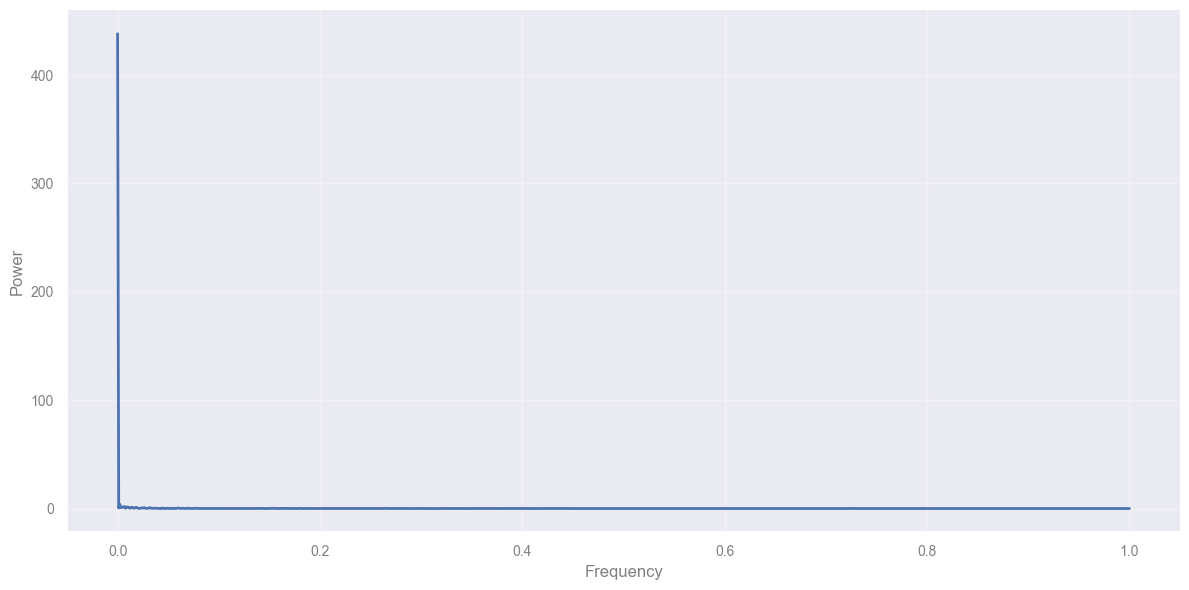

In [8]:
plt.figure(figsize=(12, 6))

# Plot the fourier transform power as a function of the frequency
plt.plot(freqs, np.abs(fft)**2)

# Make plot pretty
plt.xlabel('Frequency')
plt.ylabel('Power')

# #Zeroth frequency component is the mean of the signal, so we can ignore it
# plt.axvline(x=0, color='r', linestyle='--', label='Mean of the signal')

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [5 min]**</font>

**Objective:** Understand what the zeroth FFT component represents.

**Task:** Compute the mean count rate of the AGN light curve using the FFT result.

_Hint: the zeroth FFT component equals_ $N \cdot \bar{x}$, _where_ $\bar{x}$ is the mean.

</div>

In [ ]:
# Student: Write your code here. Add blocks as you deem fit.
mean_count_rate = ... 
print(f"Mean count rate of the light curve: {mean_count_rate:.6f} counts/s")



fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    simple_lc["time_days"], simple_lc["rate_total"],
    yerr=simple_lc["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.hlines(mean_count_rate, xmin=simple_lc["time_days"].min(), xmax=simple_lc["time_days"].max(), color="red", lw=3, ls="--", label="Mean Count Rate")
plt.tight_layout()
plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [10]:
# The zeroth FFT component equals sum(x) = N * mean(x), so:
mean_count_rate = np.real(fft[0]) / n
print(f"Mean count rate of the light curve: {mean_count_rate:.6f} counts/s")

Mean count rate of the light curve: 0.011464 counts/s


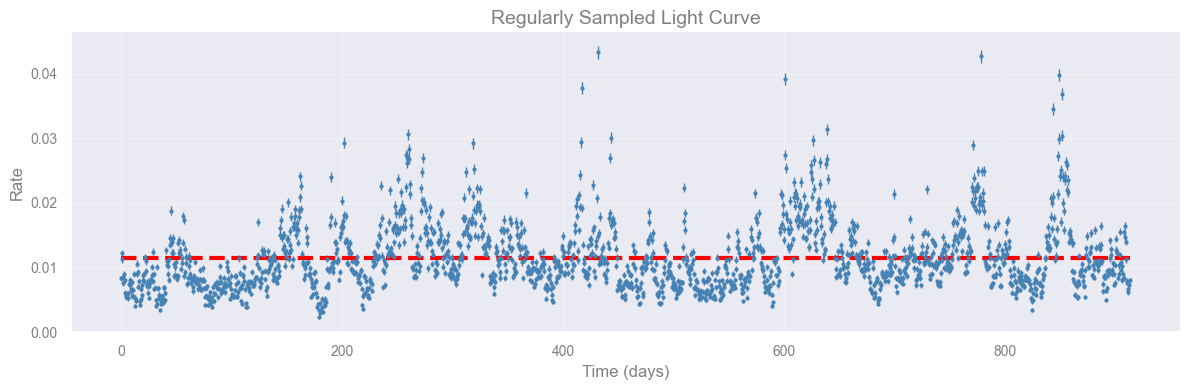

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    simple_lc["time_days"], simple_lc["rate_total"],
    yerr=simple_lc["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.hlines(mean_count_rate, xmin=simple_lc["time_days"].min(), xmax=simple_lc["time_days"].max(), color="red", lw=3, ls="--", label="Mean Count Rate")
plt.tight_layout()
plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

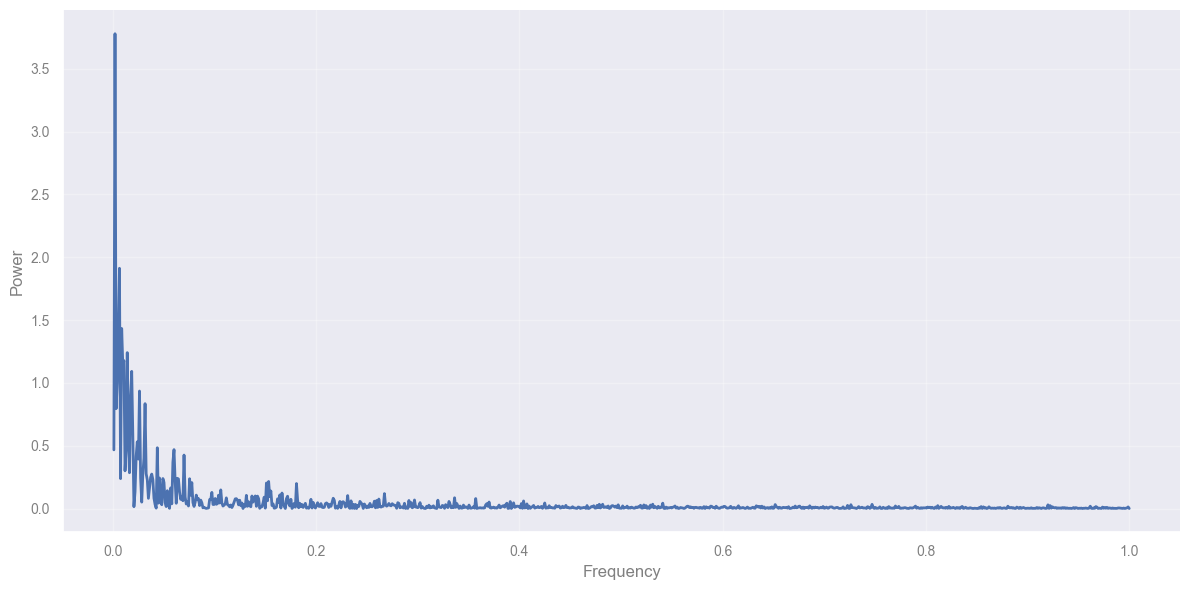

In [12]:
# plot the fourier transform power as a function of the frequency, ignoring the zeroth component

plt.figure(figsize=(12, 6))

plt.plot(freqs[1:], np.abs(fft)[1:]**2)

# Make plot pretty
plt.xlabel('Frequency')
plt.ylabel('Power')

# #Zeroth frequency component is the mean of the signal, so we can ignore it
# plt.axvline(x=0, color='r', linestyle='--', label='Mean of the signal')

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [3 min]**</font>

**Why does the zeroth FFT component is the mean of the Light curve times the Number of samples?**<br>
_Look at the DFT formula: $\tilde{x}_k = \sum_{t=0}^{N-1} x_t\, e^{-2\pi i\, k t / N}$. What happens when $k = 0$?_<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

When $k = 0$, every exponential becomes $e^0 = 1$, so $\tilde{x}_0 = \sum_{t=0}^{N-1} x_t = N \cdot \bar{x}$. The zeroth component carries the **DC offset** (the average value / the constant background level of a signal) with no oscillatory information. This is why we exclude it from the PSD and why dividing `fft[0]` by $N$ gives the mean count rate in one line.

</details>
</div>

## Power spectrum density (PSD)

Is the Fourier transform of the autocovariance:

$$f(\omega) = \sum_{h=-\infty}^{\infty} \gamma(h)\, e^{-2\pi i \omega h}.$$

This is the **Wiener–Khinchin theorem** and it is the deep reason the time-domain ($\gamma$) and frequency-domain ($f$) descriptions are equivalent: each is the Fourier transform of the other.


<!-- ### Reading the PSD

Different stochastic processes leave different signatures in the PSD:

- **White noise:** flat spectrum, $f(\omega) = \sigma^2$ — equal power at all frequencies (hence "white").
- **Periodic signal:** a sharp spike at the signal frequency (and at its harmonics if the waveform is non-sinusoidal).
- **Quasi-periodic oscillation (QPO):** a broad bump, narrower than the continuum but wider than a delta function — characteristic of damped oscillators (accreting compact objects show these prominently). -->

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[Fan Fact] Reading the PSD</summary></b>

Different stochastic processes leave different signatures in the PSD:

- **White noise:** flat spectrum, $f(\omega) = \sigma^2$ — equal power at all frequencies (hence "white").
- **Periodic signal:** a sharp spike at the signal frequency (and at its harmonics if the waveform is non-sinusoidal).
- **Quasi-periodic oscillation (QPO):** a broad bump, narrower than the continuum but wider than a delta function — characteristic of damped oscillators (accreting compact objects show these prominently).

</details>
</div>

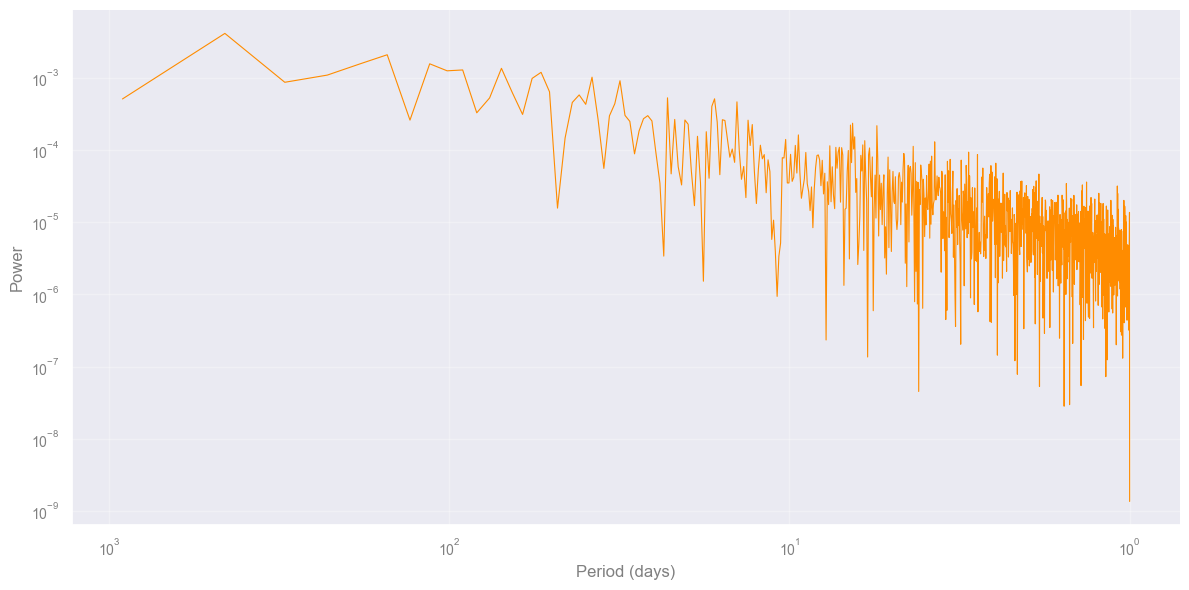

In [13]:
# calculate the one-sided power spectral density (PSD) of the light curve

psd   = (np.abs(fft) ** 2) / (n * cadence)     # one-sided PSD

# exclude the DC component (freq = 0)
freqs = freqs[1:]
psd   = psd[1:]



plt.figure(figsize=(12, 6))
plt.loglog(1 / freqs, psd, lw=0.8, color="darkorange")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("")
plt.gca().invert_xaxis()


plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [20 min]**</font>

From here it is just a matter of fitting the PSD to identify which process best describes this variability.

This data set was simulated with a PSD that follows a **bending power law**, meaning two smoothly connected power laws: one with slope $\alpha_1 = -1$ above the bending frequency, and a slope $\alpha_2 = -2$ below this characteristic bending frequency.

With that in mind, fit:
1. A bending power law
2. A simple power law

What does this tell you about the PSD?

</div>

In [ ]:
# Student: Write your code here. Add blocks as you deem fit.

def simple_powerlaw(f, A, alpha):
    return A * f**(-alpha)


def bending_powerlaw(f, A, alpha_lo, alpha_hi, f_bend):
    return A * f**(-alpha_lo) / (1.0 + (f / f_bend)**(alpha_hi - alpha_lo))



def fit_spl_psd(freqs, psd):
    """Fit a simple power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha):
        return ...

    p0    = [np.log10(np.median(psd)), 1.5]
    bounds = ([-np.inf, 0.0], [np.inf, 10.0])

    popt, pcov = ...
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A = ...,
        alpha = ...,
    )


def fit_bpl_psd(freqs, psd):
    """Fit a bending power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha_lo, alpha_hi, log_f_bend):
        return ...

    p0     = [np.log10(np.median(psd)), 1.0, 2.0, np.log10(np.median(freqs))]
    bounds = ([-np.inf, 0.0, 0.0, -np.inf], [np.inf, 6.0, 12.0, np.inf])

    popt, pcov = ...
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A = ... ,
        alpha_lo = ... ,
        alpha_hi = ... ,
        f_bend   = ... ,
    )


fit_spl = fit_spl_psd(freqs, psd)
fit_bpl = fit_bpl_psd(freqs, psd)

print("Simple power law fit")
print(f"Normalization A: {fit_spl['A']:.4e}  ± {fit_spl['A_err']:.4e}")
print(f"Slope α : {fit_spl['alpha']:.3f}  ± {fit_spl['alpha_err']:.3f}")
print()
print("Bending power law fit")
print(f"Normalization A: {fit_bpl['A']:.4e}  ± {fit_bpl['A_err']:.4e}")
print(f"Low-freq slope  α_lo: {fit_bpl['alpha_lo']:.3f}  ± {fit_bpl['alpha_lo_err']:.3f}")
print(f"High-freq slope α_hi: {fit_bpl['alpha_hi']:.3f}  ± {fit_bpl['alpha_hi_err']:.3f}")
print(f"Bend frequency  f_b: {fit_bpl['f_bend']:.4e} cycles/day  ± {fit_bpl['f_bend_err']:.4e}")
print(f"Bend timescale  T_b: {1/fit_bpl['f_bend']:.2f} days")

In [ ]:
f_model = np.geomspace(freqs.min(), freqs.max(), 500)
p_spl = simple_powerlaw(f_model, fit_spl['A'], fit_spl['alpha'])
p_bpl = bending_powerlaw(f_model, fit_bpl['A'], fit_bpl['alpha_lo'], fit_bpl['alpha_hi'], fit_bpl['f_bend'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(1 / freqs,   psd,   lw=0.8, color="darkorange", alpha=0.6, label="PSD (periodogram)")
ax.loglog(1 / f_model, p_spl, lw=2.0, color="steelblue",  ls="--",   label=rf"Simple PL  $\alpha$ = {fit_spl['alpha']:.2f}")
ax.loglog(1 / f_model, p_bpl, lw=2.0, color="crimson",               label=rf"Bending PL  $\alpha_{{lo}}$ = {fit_bpl['alpha_lo']:.2f},  $\alpha_{{hi}}$ = {fit_bpl['alpha_hi']:.2f}")
ax.axvline(1 / fit_bpl['f_bend'], ls=":", color="grey", lw=1.5,
           label=rf"$T_{{bend}}$ = {1/fit_bpl['f_bend']:.1f} days")
ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD with power law fits")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [ ]:
# Thise function will be provited

def simple_powerlaw(f, A, alpha):
    """P(f) = A * f^{-alpha}"""
    return A * f**(-alpha)


def bending_powerlaw(f, A, alpha_lo, alpha_hi, f_bend):
    """
        P(f) = A * f^{-alpha_lo} / [1 + (f / f_bend)^{alpha_hi - alpha_lo}]

    Asymptotes:  f << f_bend  →  P ∝ f^{-alpha_lo}  (low-freq slope)
                 f >> f_bend  →  P ∝ f^{-alpha_hi}  (high-freq slope)
    """
    return A * f**(-alpha_lo) / (1.0 + (f / f_bend)**(alpha_hi - alpha_lo))


# This they need to write alone

def fit_spl_psd(freqs, psd):
    """Fit a simple power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha):
        return np.log10(simple_powerlaw(f, 10**log_A, alpha))

    p0    = [np.log10(np.median(psd)), 1.5]
    bounds = ([-np.inf, 0.0], [np.inf, 10.0])

    popt, pcov = curve_fit(_log_model, freqs, log_p, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A       = 10**popt[0],  A_err      = perr[0] * 10**popt[0] * np.log(10),
        alpha   = popt[1],      alpha_err  = perr[1],
    )


def fit_bpl_psd(freqs, psd):
    """Fit a bending power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha_lo, alpha_hi, log_f_bend):
        return np.log10(bending_powerlaw(f, 10**log_A, alpha_lo, alpha_hi, 10**log_f_bend))

    p0     = [np.log10(np.median(psd)), 1.0, 2.0, np.log10(np.median(freqs))]
    bounds = ([-np.inf, 0.0, 0.0, -np.inf], [np.inf, 6.0, 12.0, np.inf])

    popt, pcov = curve_fit(_log_model, freqs, log_p, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A        = 10**popt[0],  A_err        = perr[0] * 10**popt[0] * np.log(10),
        alpha_lo = popt[1],      alpha_lo_err = perr[1],
        alpha_hi = popt[2],      alpha_hi_err = perr[2],
        f_bend   = 10**popt[3],  f_bend_err   = perr[3] * 10**popt[3] * np.log(10),
    )


fit_spl = fit_spl_psd(freqs, psd)
fit_bpl = fit_bpl_psd(freqs, psd)

print("Simple power law fit")
print(f"Normalization A: {fit_spl['A']:.4e}  ± {fit_spl['A_err']:.4e}")
print(f"Slope α : {fit_spl['alpha']:.3f}  ± {fit_spl['alpha_err']:.3f}")
print()
print("Bending power law fit")
print(f"Normalization A: {fit_bpl['A']:.4e}  ± {fit_bpl['A_err']:.4e}")
print(f"Low-freq slope  α_lo: {fit_bpl['alpha_lo']:.3f}  ± {fit_bpl['alpha_lo_err']:.3f}")
print(f"High-freq slope α_hi: {fit_bpl['alpha_hi']:.3f}  ± {fit_bpl['alpha_hi_err']:.3f}")
print(f"Bend frequency  f_b: {fit_bpl['f_bend']:.4e} cycles/day  ± {fit_bpl['f_bend_err']:.4e}")
print(f"Bend timescale  T_b: {1/fit_bpl['f_bend']:.2f} days")

Simple power law fit
  Normalization A  : 2.9194e-06  ± 1.7372e-07
  Slope α          : 1.183  ± 0.043

Bending power law fit
  Normalization A  : 2.5639e-03  ± 1.7772e-02
  Low-freq slope  α_lo  : 0.000  ± 1.137
  High-freq slope α_hi  : 1.234  ± 0.078
  Bend frequency  f_b   : 4.0001e-03 cycles/day  ± 4.4378e-03
  Bend timescale  T_b   : 250.00 days


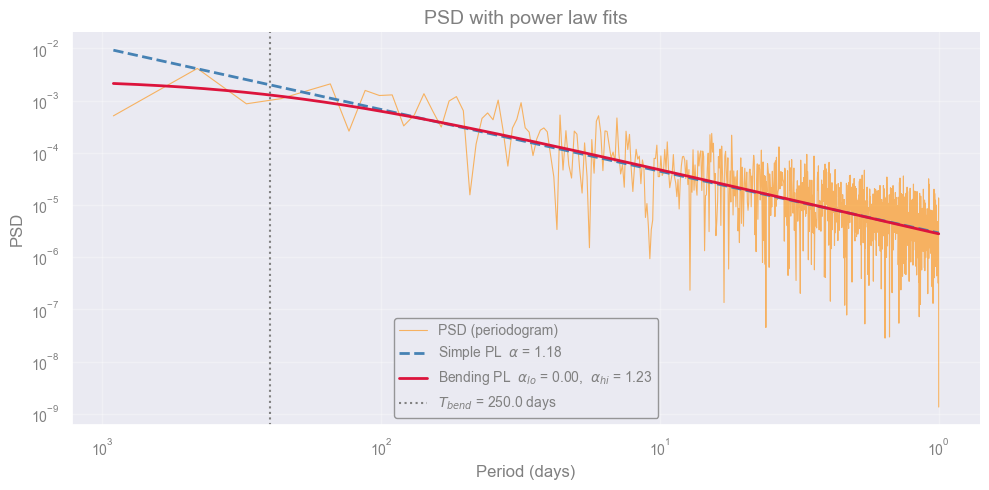

In [ ]:
f_model = np.geomspace(freqs.min(), freqs.max(), 500)
p_spl = simple_powerlaw(f_model, fit_spl['A'], fit_spl['alpha'])
p_bpl = bending_powerlaw(f_model, fit_bpl['A'], fit_bpl['alpha_lo'], fit_bpl['alpha_hi'], fit_bpl['f_bend'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(1 / freqs,   psd,   lw=0.8, color="darkorange", alpha=0.6, label="PSD (periodogram)")
ax.loglog(1 / f_model, p_spl, lw=2.0, color="steelblue",  ls="--",   label=rf"Simple PL  $\alpha$ = {fit_spl['alpha']:.2f}")
ax.loglog(1 / f_model, p_bpl, lw=2.0, color="crimson",               label=rf"Bending PL  $\alpha_{{lo}}$ = {fit_bpl['alpha_lo']:.2f},  $\alpha_{{hi}}$ = {fit_bpl['alpha_hi']:.2f}")
ax.axvline(1 / fit_bpl['f_bend'], ls=":", color="grey", lw=1.5,
           label=rf"$T_{{bend}}$ = {1/fit_bpl['f_bend']:.1f} days")
ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD with power law fits")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

We are probing lower frequencies in the PSD, meaning we are capturing the long-timescale information of the system.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

# What is happening in reality? 

<img src="images/facilities_meme.jpg" width=650 style="display:block; margin-left:auto; margin-right:auto;">



Real time series *especially* in astronomy  are rarely complete. Gaps arise from:

- **Observing constraints:** daytime, weather, the target being below the horizon, the Moon being too close, the satellite being in the South Atlantic Anomaly.
- **Instrumental issues:** detector saturation, cosmic-ray hits, telemetry dropouts, scheduled downtime.
- **Irregular cadence by design:** queue-scheduled observations, target-of-opportunity interrupts.

The result is a series $\{x_t\}$ where some $t \in T_0$ have no observation. This is a problem because most classical time series tools (ACF estimation, ARMA fitting, FFT-based spectral analysis) assume evenly-spaced, complete data.

In [17]:
realistic_lc = pd.read_csv("data/Lc_irregular.csv")

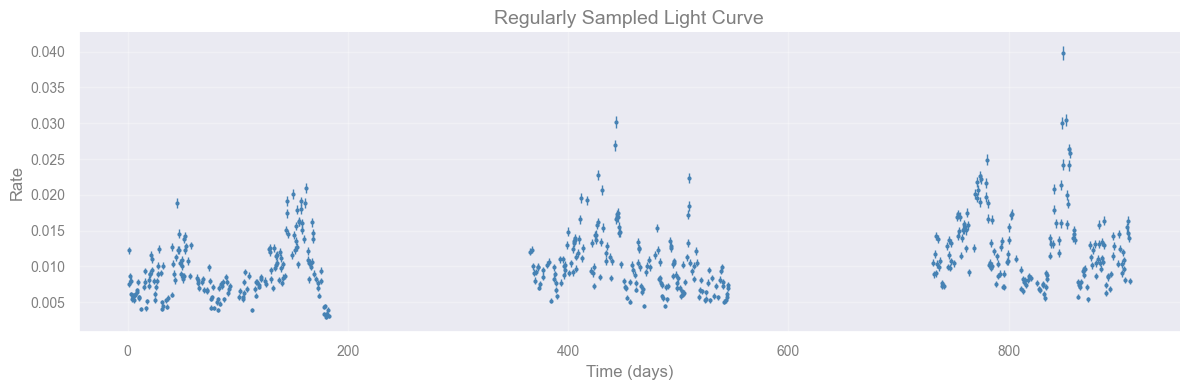

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    realistic_lc["time_days"], realistic_lc["rate_total"],
    yerr=realistic_lc["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [5 min]**</font>

**What would happen if we applied `np.fft.rfft` directly to this irregularly sampled light curve?**<br>
_Consider: what does the FFT assume about the spacing between points? What would the "frequencies" $\omega_k = k/(N\Delta t)$ mean if $\Delta t$ is not constant?_<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The FFT assumes **uniform spacing** $\Delta t$. If we pass it irregularly spaced data, numpy treats the array indices as if they were evenly spaced — which they are not. The computed "frequencies" correspond to an imaginary uniform cadence, not the real observation times, so the result is meaningless. This motivates methods like the **Lomb–Scargle periodogram** and the **CARMA likelihood** that work natively with arbitrary timestamps.

</details>
</div>

In [19]:
result_real = check_sampling(realistic_lc["time_days"].values, min_gap=30)
print(result_real)

Sampling: IRREGULAR
  Points  : 528
  Span    : 909.000
  Cadence : 0.5000 (std=11.3016)
  Gaps    : 2
    [182.500 – 365.500]  duration=183.0 days
    [545.500 – 731.000]  duration=185.5 days


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**Approaches to handling irregularly sampled data:**

- **Ignore and work irregularly:** use methods that natively handle uneven sampling (Lomb–Scargle periodogram, structure functions, Gaussian processes). $\leftarrow$ _what we do in this notebook_
- **Interpolation:** fill gaps with a deterministic rule (linear, spline, nearest neighbor). Simple, but introduces artificial correlations and underestimates uncertainty in the gaps.
- **Model-based imputation:** treat missing values as latent variables and infer them under a probabilistic model — propagates uncertainty correctly and allows joint inference on parameters and missing data.

</div>

# CARMA Modeling

## The problem with irregular sampling

All the tools we have used so far — ACF estimation, FFT, periodogram fitting — assume that data are **evenly spaced in time**. Real astronomical light curves rarely are. Observations are interrupted by the day/night cycle, weather, satellite orbits, and scheduling constraints.

When data are irregularly sampled, the discrete-time ARMA recursion $X_t = \phi X_{t-1} + Z_t$ breaks down: "lag $h = 1$" has no fixed physical meaning, and the model cannot accommodate arbitrary observation times.

## The solution: work in continuous time

The natural fix is to define the model for **all** $t \in \mathbb{R}$, so that any sampling pattern is automatically handled. This leads to **CARMA** — Continuous AutoRegressive Moving Average models.

## Intuition first: the Damped Random Walk (DRW)

The simplest CARMA model — **CAR(1)**, also known as the **Damped Random Walk (DRW)** or **Ornstein–Uhlenbeck (OU) process** — is described by the stochastic differential equation:

$$dX(t) = -\frac{1}{\tau}\, X(t)\, dt + \sigma\, dW(t)$$

Think of it this way:
- The term $-X(t)/\tau$ acts like a **spring**: it pulls the process back toward zero. The larger $\tau$, the weaker the restoring force.
- The term $\sigma\, dW(t)$ is a continuous **random kick** (Gaussian white noise driving the process).
- The competition between these two produces a process that **wanders randomly but has a characteristic memory timescale $\tau$**: correlations decay as $e^{-|\Delta t|/\tau}$.

The two parameters have direct physical meaning:
| Parameter | Meaning |
|-----------|---------|
| $\tau$ | **Relaxation timescale** — how long the system "remembers" past states. For an AGN this is related to the size of the emission region. |
| $\sigma$ | **Variability amplitude** — how strongly the process is driven. |

## Connection to Gaussian Processes

The DRW/CAR(1) is not just a stochastic differential equation — it is also a **Gaussian Process (GP)** with an exponential covariance kernel:

$$k(\Delta t) = \sigma^2 \exp\!\left(-\frac{|\Delta t|}{\tau}\right)$$

This means that **fitting CARMA(1,0) is exactly GP regression** with a physically motivated kernel. Given the observations $\mathbf{y}$ at times $\mathbf{t}$, the GP log-likelihood is:

$$\log p(\mathbf{y} \mid \sigma, \tau) = -\frac{1}{2}\left(\mathbf{y}^\top K^{-1} \mathbf{y} + \log|K| + N\log 2\pi\right)$$

where $K_{ij} = k(t_i - t_j) + \sigma_{\rm noise,i}^2\, \delta_{ij}$ incorporates both the process covariance and the measurement errors. This is exactly what we compute in the code below using a Cholesky decomposition.

<!-- The equivalences are worth remembering:

| Name | Same thing? |
|------|-------------|
| CARMA(1,0) | ✓ |
| Damped Random Walk (DRW) | ✓ |
| Ornstein–Uhlenbeck process | ✓ |
| GP with exponential kernel | ✓ | -->

## The general CARMA($p$, $q$) model

A **CARMA($p, q$)** process is the stationary solution of the stochastic differential equation:

$$\frac{d^p X}{dt^p} + \alpha_{p-1}\frac{d^{p-1} X}{dt^{p-1}} + \cdots + \alpha_0 X = \beta_0\, \epsilon(t) + \cdots + \beta_q\frac{d^q \epsilon}{dt^q}$$

where $\epsilon(t)$ is continuous-time white noise. The DRW above is the special case $p=1$, $q=0$.

Higher-order CARMA models can produce richer behaviours:
- **CARMA(2,0) / CARMA(2,1):** can model a stochastically driven **damped harmonic oscillator**, producing a bump in the PSD — the signature of a quasi-periodic oscillation (QPO).

## How we fit it

Because the model is defined in continuous time, the likelihood can be evaluated **exactly** at any set of observation times — no interpolation, no gap-filling. We then explore the posterior of $\tau$ and $\sigma$ using MCMC.


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**The DRW, the Ornstein–Uhlenbeck process, CARMA(1,0), and a GP with an exponential kernel are four names for the _same_ stochastic process.** Recognising this equivalence lets you switch between the SDE and GP formalisms freely — the code below exploits the GP interpretation to evaluate the exact likelihood via a Cholesky decomposition.

</div>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[Derivation] From the DRW SDE to the GP log-likelihood (click here to expand)</summary></b>

The DRW SDE $dX(t) = -X(t)/\tau\,dt + \sigma\,dW(t)$ has the stationary covariance:

$$k(\Delta t) = \sigma^2 \exp\!\left(-\frac{|\Delta t|}{\tau}\right)$$

Given $N$ observations $\mathbf{y}$ at times $\mathbf{t}$, define the kernel matrix

$$K_{ij} = k(t_i - t_j) + \sigma_{\mathrm{noise},i}^2\,\delta_{ij}$$

which folds in both the process covariance and the measurement uncertainties. Since any finite collection of GP values is jointly Gaussian, $\mathbf{y} \sim \mathcal{N}(\mathbf{0}, K)$, so the log-likelihood is:

$$\log p(\mathbf{y}|\sigma,\tau) = -\tfrac{1}{2}\bigl(\mathbf{y}^\top K^{-1}\mathbf{y} + \log|K| + N\log 2\pi\bigr)$$

We evaluate this via a **Cholesky decomposition** $K = L L^\top$ ($\mathcal{O}(N^3)$ cost), which is what `cho_factor` and `cho_solve` do in the code below. $~$ &#9632;

</details>
</div>

In [20]:
t    = realistic_lc["time_days"].values
y    = realistic_lc["rate_total"].values
yerr = realistic_lc["err"].values

y_mean = np.mean(y)
y_res  = y - y_mean          # GP models zero-mean residuals

# DRW (CARMA 1,0) covariance: k(Δt) = σ² exp(−|Δt| / τ)
def drw_kernel(t1, t2, sigma, tau):
    return sigma**2 * np.exp(-np.abs(t1[:, None] - t2[None, :]) / tau)

#  Gaussian log-likelihood 
def log_likelihood(log_sigma, log_tau):
    sigma, tau = np.exp(log_sigma), np.exp(log_tau)
    K = drw_kernel(t, t, sigma, tau)
    K[np.diag_indices_from(K)] += yerr**2
    try:
        cf      = cho_factor(K, lower=True)
        alpha   = cho_solve(cf, y_res)
        log_det = 2.0 * np.sum(np.log(np.diag(cf[0])))
        return -0.5 * (y_res @ alpha + log_det + len(t) * np.log(2 * np.pi))
    except np.linalg.LinAlgError:
        return -np.inf

#  Flat log-prior in log space
def log_prior(log_sigma, log_tau):
    if -12 < log_sigma < -2 and np.log(0.5) < log_tau < np.log(2000):
        return 0.0
    return -np.inf

#  Log-posterior (emcee signature: single array of params)
def log_posterior(params):
    lp = log_prior(*params)
    return lp + log_likelihood(*params) if np.isfinite(lp) else -np.inf

#  MAP estimate as starting point for MCMC
result = minimize(
    lambda p: -log_posterior(p),
    x0=[np.log(0.002), np.log(50)],
    method="Nelder-Mead",
    options={"maxiter": 5000},
)
p_map = result.x
print(f"MAP  σ = {np.exp(p_map[0]):.4e}   τ = {np.exp(p_map[1]):.1f} days")

#  MCMC
ndim, nwalkers = 2, 8
p0 = p_map + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0, 2000, progress=True)

MAP  σ = 4.5593e-03   τ = 3.5 days


100%|██████████| 2000/2000 [00:30<00:00, 65.63it/s]


State([[-5.40950136  1.22879514]
 [-5.42903622  1.25994546]
 [-5.33236031  1.25457816]
 [-5.40118172  1.2822978 ]
 [-5.27352533  1.42068866]
 [-5.43035808  1.10681244]
 [-5.42450043  1.23163605]
 [-5.42074067  1.22286163]], log_prob=[2340.62241764 2339.755149   2339.52959707 2340.37215767 2338.90402753
 2340.22461452 2340.28263322 2340.45184666], blobs=None, random_state=('MT19937', array([ 860192877, 2198812392, 2129638728, 1227908493,  806941469,
       3916613449,  904131701,  910152331,   39354804, 2175894486,
        111970081, 2208751761,  622666736, 2096033099,  913915096,
       2431582155, 3595089152,  850712222, 3706417065, 3841115842,
       2653384167, 3416797468, 2440770128, 3960576048, 1977019300,
        572216968, 1381088768, 1544538464, 1898773092,  152502471,
        989845175, 2815265727, 3475783082, 3309499195, 1886546918,
       3634005526, 2405083090, 3430041864, 3933926732, 1504079812,
       2640137260, 3953093256, 2023214845, 2277956870, 3749739657,
       2155

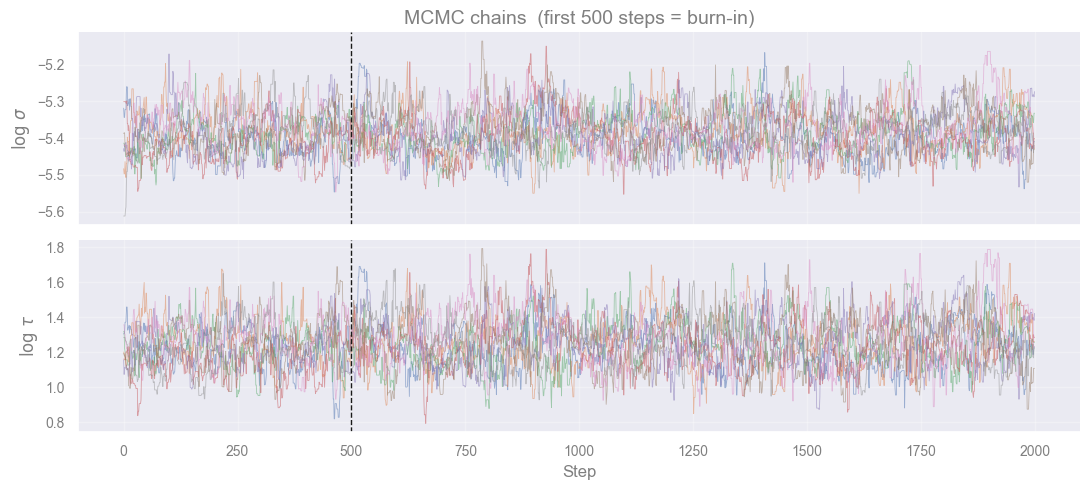

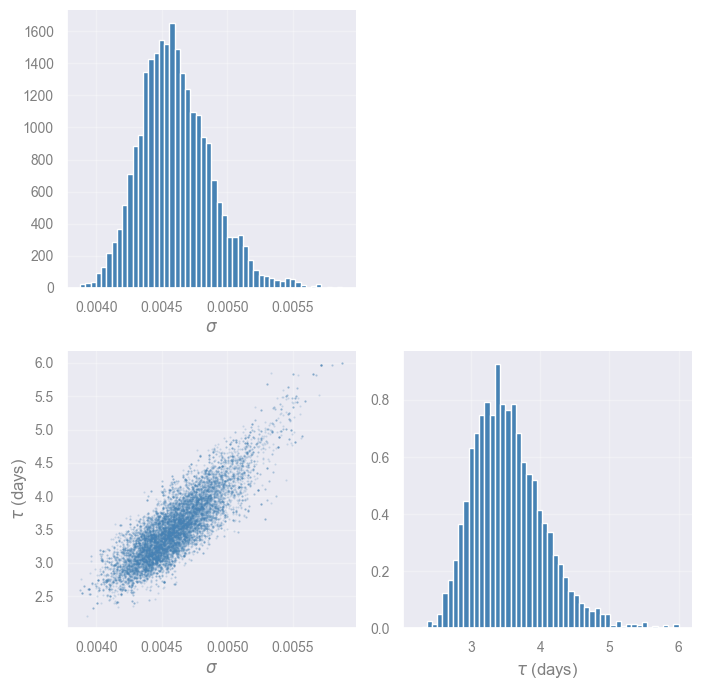

σ = 4.5823e-03  +2.8034e-04  −2.3423e-04
τ = 3.5  +0.6  −0.4  days


In [21]:
#  MCMC chains
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, [r"$\log\,\sigma$", r"$\log\,\tau$"])):
    ax.plot(sampler.get_chain()[:, :, i], alpha=0.5, lw=0.6)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC chains  (first 500 steps = burn-in)")
axes[0].axvline(500, color="k", lw=1, ls="--")
axes[1].axvline(500, color="k", lw=1, ls="--")
plt.tight_layout()
plt.show()

#  Posterior samples (discard burn-in)
flat = sampler.get_chain(discard=500, flat=True)
sigma_s = np.exp(flat[:, 0])
tau_s   = np.exp(flat[:, 1])

#  Corner-style scatter plot ---
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes[0, 0].hist(sigma_s, bins=50, color="steelblue", density=True)
axes[0, 0].set_xlabel(r"$\sigma$")
axes[1, 1].hist(tau_s,   bins=50, color="steelblue", density=True)
axes[1, 1].set_xlabel(r"$\tau$ (days)")
axes[1, 0].scatter(sigma_s, tau_s, s=0.3, alpha=0.2, color="steelblue")
axes[1, 0].set_xlabel(r"$\sigma$");  axes[1, 0].set_ylabel(r"$\tau$ (days)")
axes[0, 1].axis("off")
plt.tight_layout()
plt.show()

#  Parameter summary ---
def pm(x): return np.median(x), np.percentile(x,84)-np.median(x), np.median(x)-np.percentile(x,16)
sm, sp, sn = pm(sigma_s)
tm, tp, tn = pm(tau_s)
print(f"σ = {sm:.4e}  +{sp:.4e}  −{sn:.4e}")
print(f"τ = {tm:.1f}  +{tp:.1f}  −{tn:.1f}  days")

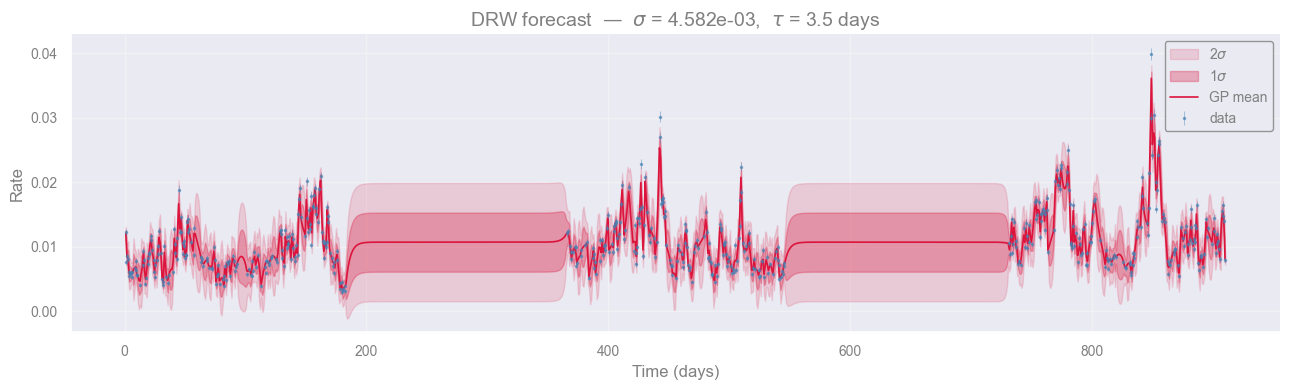

In [22]:
#  GP posterior prediction (forecasting) 
# Use median MCMC parameters
sigma_med = np.median(sigma_s)
tau_med   = np.median(tau_s)

t_pred = np.linspace(t.min(), t.max(), 1000)

K_obs = drw_kernel(t, t, sigma_med, tau_med)
K_obs[np.diag_indices_from(K_obs)] += yerr**2
K_xo  = drw_kernel(t_pred, t, sigma_med, tau_med)   # (N_pred, N_obs)

cf    = cho_factor(K_obs, lower=True)
mu    = K_xo @ cho_solve(cf, y_res) + y_mean         # posterior mean

v   = cho_solve(cf, K_xo.T)                          # (N_obs, N_pred)
var = sigma_med**2 - np.sum(K_xo.T * v, axis=0)      # posterior variance (diagonal only)
std = np.sqrt(np.maximum(var, 0))

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(t_pred, mu - 2*std, mu + 2*std, alpha=0.15, color="crimson", label=r"2$\sigma$")
ax.fill_between(t_pred, mu -   std, mu +   std, alpha=0.30, color="crimson", label=r"1$\sigma$")
ax.plot(t_pred, mu, lw=1.2, color="crimson", label="GP mean")
ax.errorbar(t, y, yerr=yerr, fmt=".", ms=3, lw=0.5, color="steelblue", alpha=0.6, label="data")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title(rf"DRW forecast  —  $\sigma$ = {sigma_med:.3e},  $\tau$ = {tau_med:.1f} days")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task [5 min]**</font>

**Inspect the DRW posterior prediction above.**

- Where is the $1\sigma$ uncertainty band widest? Why does it widen there?
- Does the GP mean pass exactly through every data point, or between them?
- What would happen to the uncertainty at times well outside the observed baseline?


</div>

<u>**Connection to the power spectrum**</u>

The CARMA PSD has a closed form:

$$f(\omega) = \frac{\sigma^2}{2\pi}\, \frac{\left|\sum_{j=0}^{q} \beta_j (i\omega)^j \right|^2}{\left|\sum_{j=0}^{p} \alpha_j (i\omega)^j\right|^2}, \quad \alpha_p \equiv 1.$$

This is a **rational function of $\omega$** — a ratio of polynomials. For the DRW (CAR(1)), this becomes the classic Lorentzian:

$$f(\omega) \propto \frac{1}{\omega^2 + (1/\tau)^2},$$

flat for $\omega \ll 1/\tau$ and falling as $\omega^{-2}$ for $\omega \gg 1/\tau$ — the canonical "broken power-law" shape seen in AGN light curves. Higher-order CARMA can reproduce more complex broken-power-law and QPO-bearing spectra without needing infinite-parameter models. This is the main reason CARMA has become a standard tool for AGN variability, X-ray binary timing, and stellar microvariability.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**The CARMA PSD is always a rational function of frequency** — a ratio of two polynomials in $\omega$. This means a CARMA($p$, $q$) model can fit _any_ broken-power-law or QPO-shaped spectrum using only $p + q + 1$ parameters, without assuming a specific physical mechanism for the variability.

</div>

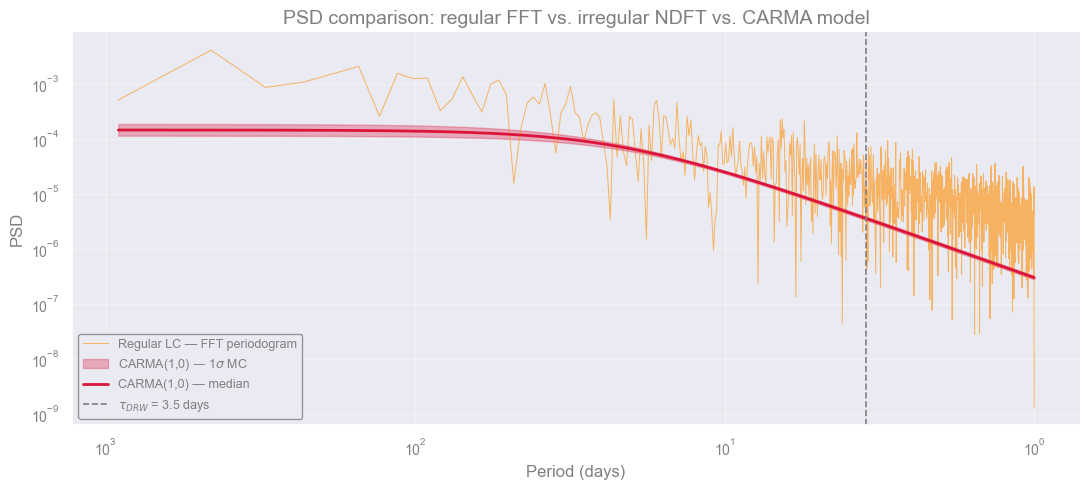

In [23]:
#  CARMA(1,0) / DRW PSD: P(f) = 2σ²τ / (1 + (2πfτ)²) 
dt_min  = np.min(np.diff(np.sort(t)))
f_carma = np.geomspace(1.0 / t.max(), 1.0 / (2.0 * dt_min), 400)

psd_mc = np.array([
    2 * s**2 * tau / (1 + (2 * np.pi * f_carma * tau)**2)
    for s, tau in zip(sigma_s[::5], tau_s[::5])
])
psd_med = np.median(psd_mc,         axis=0)
psd_lo  = np.percentile(psd_mc, 16, axis=0)
psd_hi  = np.percentile(psd_mc, 84, axis=0)


#  Plot 
fig, ax = plt.subplots(figsize=(11, 5))

ax.loglog(1 / freqs,   psd,    lw=0.7, color="darkorange", alpha=0.6, label="Regular LC — FFT periodogram")
ax.fill_between(1 / f_carma, psd_lo, psd_hi,
                alpha=0.3, color="crimson", label=r"CARMA(1,0) — 1$\sigma$ MC")
ax.loglog(1 / f_carma, psd_med, lw=2, color="crimson", label="CARMA(1,0) — median")
ax.axvline(tau_med, ls="--", color="grey", lw=1.2,
           label=rf"$\tau_{{DRW}}$ = {tau_med:.1f} days")

ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD comparison: regular FFT vs. irregular NDFT vs. CARMA model")
ax.invert_xaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [10 min]**</font>

**Objective:** Understand how prior choice affects the DRW posterior for $\tau$.

**Task:** Re-run the MCMC fit with three different prior ranges for $\log\tau$:

1. **Tight prior:** $\tau \in [0.1, 10]$ days
2. **Current prior:** $\tau \in [0.5, 2000]$ days _(baseline — already run above)_
3. **Wide prior:** $\tau \in [0.01, 10\,000]$ days

_In particular, you must:_

1. Modify `log_prior` to enforce each $\tau$ range
2. Re-run `sampler.run_mcmc` for 500 steps for each case
3. Overplot the three marginal posteriors of $\tau$ on the same figure
4. **Report:** does the posterior change significantly? What does this tell you about how informative the data are about $\tau$?

**Hint:** use `sampler.get_chain(discard=100, flat=True)[:, 1]` to get $\log\tau$ samples.

</div>

In [ ]:
# ── Prior ranges to compare ──────────────────────────────────────────────────
prior_configs = [
    ...
]
colors = ["steelblue", "crimson", "darkorange"]

fig, ax = plt.subplots(figsize=(9, 4))
tau_results = {}

for (label, log_tau_min, log_tau_max), color in zip(prior_configs, colors):

    # ── Redefine log_prior with this τ range ─────────────────────────────────
    ...

    log_post_new = ...

    # ── Start walkers near MAP, clipped to new prior ──────────────────────────
    p0 = p_map + 0.05 * np.random.randn(nwalkers, ndim)
    p0[:, 1] = np.clip(p0[:, 1], log_tau_min + 0.05, log_tau_max - 0.05)

    samp = emcee.EnsembleSampler(nwalkers, ndim, log_post_new)
    samp.run_mcmc(p0, 500, progress=False)

    flat = samp.get_chain(discard=100, flat=True)
    tau_post = np.exp(flat[:, 1])
    tau_results[label] = tau_post

    ax.hist(tau_post, bins=60, density=True, alpha=0.55, color=color, label=label)

ax.set_xlabel(r"$\tau$ (days)")
ax.set_ylabel("Posterior density")
ax.set_title(r"DRW posterior for $\tau$ under three priors")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Prior':<40}  {'median τ':>10}  {'16th%':>8}  {'84th%':>8}")
print("-" * 72)
for label, tau_post in tau_results.items():
    med = np.median(tau_post)
    lo  = np.percentile(tau_post, 16)
    hi  = np.percentile(tau_post, 84)
    print(f"{label:<40}  {med:>10.2f}  {lo:>8.2f}  {hi:>8.2f}")

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

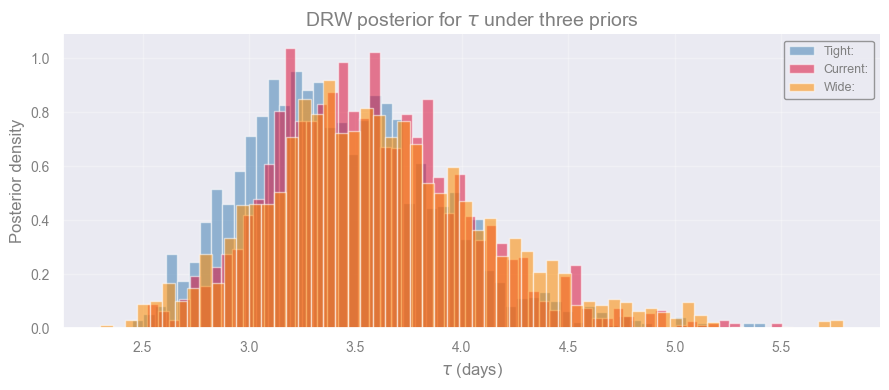

Prior                                       median τ     16th%     84th%
------------------------------------------------------------------------
Tight:                                          3.40      3.00      3.89
Current:                                        3.53      3.14      4.02
Wide:                                           3.56      3.11      4.13

Interpretation:
  If the three posteriors largely overlap → the data constrain τ well;
  the prior has little influence (data are informative).
  If they diverge → the data are not tight enough on τ and
  the prior is pulling the result (prior-dominated regime).


In [27]:
# ── Prior ranges to compare ──────────────────────────────────────────────────
prior_configs = [
    ("Tight:",   np.log(0.1),   np.log(10)),
    ("Current:",  np.log(0.5),   np.log(2000)),
    ("Wide:", np.log(0.01),  np.log(10000)),
]
colors = ["steelblue", "crimson", "darkorange"]

fig, ax = plt.subplots(figsize=(9, 4))
tau_results = {}

for (label, log_tau_min, log_tau_max), color in zip(prior_configs, colors):

    # ── Redefine log_prior with this τ range ─────────────────────────────────
    def make_log_posterior(lt_min, lt_max):
        def _lp(params):
            log_sigma, log_tau = params
            if not (-12 < log_sigma < -2 and lt_min < log_tau < lt_max):
                return -np.inf
            return log_likelihood(log_sigma, log_tau)
        return _lp

    log_post_new = make_log_posterior(log_tau_min, log_tau_max)

    # ── Start walkers near MAP, clipped to new prior ──────────────────────────
    p0 = p_map + 0.05 * np.random.randn(nwalkers, ndim)
    p0[:, 1] = np.clip(p0[:, 1], log_tau_min + 0.05, log_tau_max - 0.05)

    samp = emcee.EnsembleSampler(nwalkers, ndim, log_post_new)
    samp.run_mcmc(p0, 500, progress=False)

    flat = samp.get_chain(discard=100, flat=True)
    tau_post = np.exp(flat[:, 1])
    tau_results[label] = tau_post

    ax.hist(tau_post, bins=60, density=True, alpha=0.55, color=color, label=label)

ax.set_xlabel(r"$\tau$ (days)")
ax.set_ylabel("Posterior density")
ax.set_title(r"DRW posterior for $\tau$ under three priors")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Prior':<40}  {'median τ':>10}  {'16th%':>8}  {'84th%':>8}")
print("-" * 72)
for label, tau_post in tau_results.items():
    med = np.median(tau_post)
    lo  = np.percentile(tau_post, 16)
    hi  = np.percentile(tau_post, 84)
    print(f"{label:<40}  {med:>10.2f}  {lo:>8.2f}  {hi:>8.2f}")

print()
print("Interpretation:")
print("  If the three posteriors largely overlap → the data constrain τ well;")
print("  the prior has little influence (data are informative).")
print("  If they diverge → the data are not tight enough on τ and")
print("  the prior is pulling the result (prior-dominated regime).")


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>

In [26]:
###EOF